# AG2 - Actividad Guiada 2

* **Nombre:** Marcos Lévano Huamaccto
* **Link a Google Colab:** [Acceder al Cuaderno Interactivo](https://colab.research.google.com/drive/16n_RLlnGn-6S0DldSvsdKknJc0ErM9Oz?usp=sharing)
* **Repositorio GitHub:** [Ver Código Fuente](https://github.com/marlev88/AlgoritmosOptimizacion)

## Ejecuciones de los algoritmos

In [16]:
import math

### Programación Dinámica. Viaje por el rio

* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

### Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

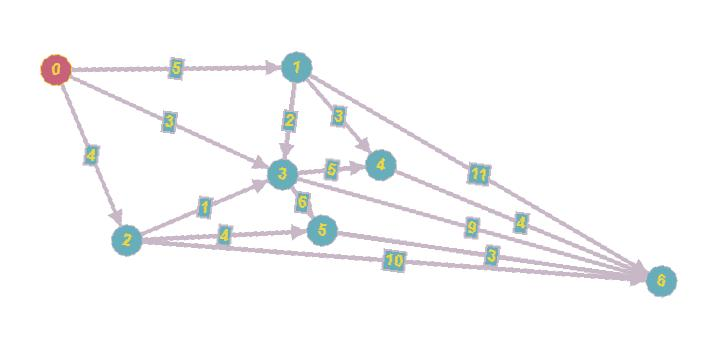

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [17]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [18]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [4]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [19]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

### Problema de Asignacion de tarea

In [20]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [21]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR


valor((3,2,  ),COSTES)

34

In [22]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [23]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [24]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [25]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


### Descenso del gradiente

In [12]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc
import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [13]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

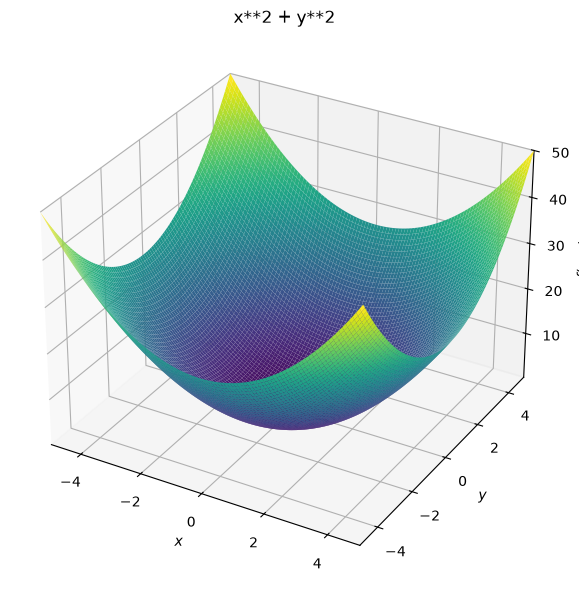

In [14]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')

plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(6,6))

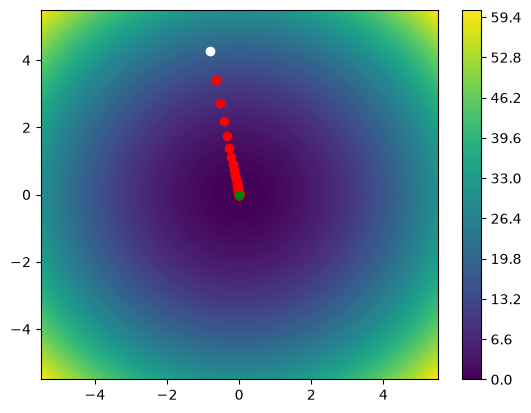

Solucion: [-1.16305205228283e-05, 6.102182314857823e-05] 3.858931908008288e-09


In [15]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$


In [167]:
# Definimos la función dada
f = lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )

## Solución para la pregunta

El razonamiento que emplearé será el siguiente:

1) Graficar la superficie.
2) Explorar el dominio de forma visual.
3) Identificar posibles mínimos.
4) Elegir puntos iniciales.
5) Ejecutar el modelo optmizador.
6) Analizar convergencia.
7) Interpretar si los mínimos encontrados son locales o globales.


Primero visualizamos para conocer como es el caso de la función. Donde podemos ver múltiples valles y cimas.

### Visualización del caso

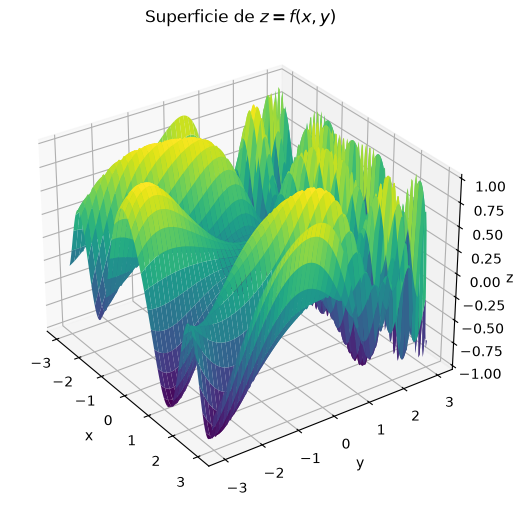

In [26]:
# Importar liberias
import numpy as np
import matplotlib.pyplot as plt

# Dominio definido
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)

X, Y = np.meshgrid(x, y)

# Función dado en el ejercicio
Z = np.sin(0.5 * X**2 - 0.25 * Y**2 + 3) * np.cos(2 * X + 1 - np.exp(Y))

# Gráfico 3D
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z', labelpad=0.4)
ax.set_title('Superficie de $z = f(x,y)$')
ax.view_init(elev=30, azim=-35)
plt.show()

En el gráfico podemos observar que la superficie es no convexa, donde se observa múltiples valles y cimas.

La visualización previa entrega información valiosa sobre la topología de la función en estudio.

### Un gráfico de contornos para observar mejor los valles y cimas: Explorar e identificar posibles mínimos

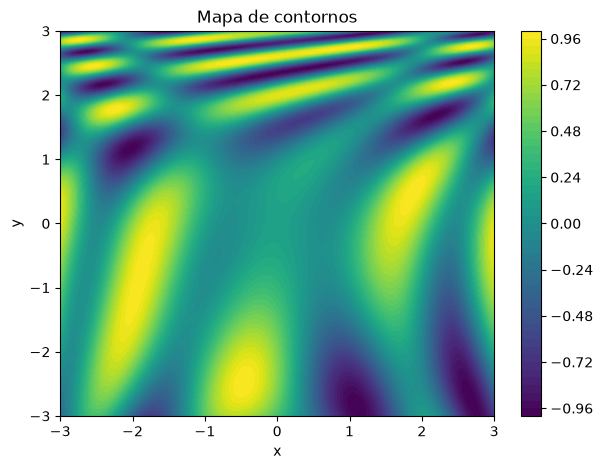

In [27]:
plt.figure(figsize=(7,5))

cont = plt.contourf(X, Y, Z, levels=50)
plt.colorbar(cont)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapa de contornos")
plt.show()

En el gráfico podemos observar:

* Color amarillo valores altos (cercanos a +1)
* Color oscuro (morados) valores bajos (cercanos a -1)
* Color verde opaco (cercanos a 0)

Podemos observar varios colores oscuros (morados), lo que confirma que la función tienes muchos mínimos locales. Por ejemplo cerca de $(1, -2.8)$, cerca de $(2.5, -2.5)$, cerca de $(-2, 1)$.

El gráfico nos permite seleccionar puntos candidatos iniciales.

### Implememtación de la estrategia Descenso del Gradiente - AGD

In [28]:
# Función definida en la pregunta
def f(x, y):
    return np.sin(0.5*x**2 - 0.25*y**2 + 3) * np.cos(2*x + 1 - np.exp(y))

En el siguiente método se usa la estrategia de diferencias finitas, para resolver las derivadas parciales.
Esta idea viene de la definición de la derivada:

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

Luego para la derivada parcial respecto a $x$,

$$\frac{\partial f}{\partial x} \approx \frac{f(x + h, y) - f(x - h, y)}{2h}$$

Luego para la derivada parcial respecto a $y$,

$$\frac{\partial f}{\partial y} \approx \frac{f(x, y + h) - f(x, y - h)}{2h}$$

Donde el Gradiente sería,

$$\nabla f(x,y) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)$$

In [29]:
# Método para aproximación de las derivadas parciales mediante diferencias finitas para el calculo del Gradiente.
def gradiente_numerico(x, y, h=1e-5):
    df_dx = (f(x + h, y) - f(x - h, y)) / (2*h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2*h)
    return np.array([df_dx, df_dy])

En el siguiente método se aplica el Algoritmo Gradiente Descendente,
$$
\begin{aligned}
x_{k+1} &= x_k - \alpha \frac{\partial f}{\partial x} \\
y_{k+1} &= y_k - \alpha \frac{\partial f}{\partial y}
\end{aligned}
$$

Este proceso se repite varias veces, el cual es un proceso iterativo de optimización.

In [30]:
# Algoritmo Gradiente Descendente - AGD
def gradiente_descendente(x0, y0, alpha=0.01, iteraciones=500):
    x, y = x0, y0
    trayectoria = [(x, y, f(x, y))]
    
    for i in range(iteraciones):
        grad = gradiente_numerico(x, y)
        
        x = x - alpha * grad[0]
        y = y - alpha * grad[1]
        
        trayectoria.append((x, y, f(x, y)))
    
    return np.array(trayectoria)

### Prueba 1

In [31]:
# Llamada del AGD para un punto de partid x0=0, y0=0, alpha = 0.01, y para 500 iteraciones.
trayectoria = gradiente_descendente(x0=0, y0=0, alpha=0.01, iteraciones=500)

print("x final:", trayectoria[-1, 0])
print("y final:", trayectoria[-1, 1])
print("f final:", trayectoria[-1, 2])

print(trayectoria.shape)

x final: -6.443318101290174e-10
y final: 1.0869083411080283e-10
f final: 0.1411200080598672
(501, 3)


### Prueba 2

In [32]:
# Llamada del AGD para un punto de partid x0 = 2, y0 = -2, alpha = 0.01, y para 500 iteraciones.
trayectoria = gradiente_descendente(x0=2, y0=-2, alpha=0.01, iteraciones=500)

print("x final:", trayectoria[-1, 0])
print("y final:", trayectoria[-1, 1])
print("f final:", trayectoria[-1, 2])

x final: 2.662002109094256
y final: -2.6934425024547677
f final: -0.9994943148833673


### Tomamdo varios puntos iniciales $x_0, y_0$ cercanos a valles (mínimos)

In [33]:
puntos = [
    (0, 0),
    (2, -2),
    (-2, -2),
    (2, 2),
    (-2, 2)
]

for x0, y0 in puntos:
    trayectoria = gradiente_descendente(x0=x0, y0=y0, alpha=0.01, iteraciones=500)
    print("Inicio:", (x0, y0))
    print("Final:", trayectoria[-1, 0], trayectoria[-1, 1])
    print("f final:", trayectoria[-1, 2])
    print()

Inicio: (0, 0)
Final: -6.443318101290174e-10 1.0869083411080283e-10
f final: 0.1411200080598672

Inicio: (2, -2)
Final: 2.662002109094256 -2.6934425024547677
f final: -0.9994943148833673

Inicio: (-2, -2)
Final: -2.053227008668906 -3.757366893482824
f final: -0.9999014063744369

Inicio: (2, 2)
Final: 2.2017866045340644 1.6870604355512084
f final: -0.9999999999999962

Inicio: (-2, 2)
Final: -2.404006299785778 2.1700084460983797
f final: -1.0



### Convergencia e interpretación
En esta parte la secuencia de iteraciones se acercan cada vez más a un valor o punto estable.
Decimos que el algoritmo está convergiendo porque los cambios son cada vez menores.

Debemos tener en cuenta que el AGD puede converger a:
* Mínimo local
* Mínimo global
* Punto silla
* Quedarse estancado con errores numéricos

En el caso de partida para $x_0 = 2, y_0 =-2$ las iteraciones se estabilizan cerca de $(2.662,−2.693)$. 
Podemos decir que el algoritmo convergió a un mínimo local (muy cercano al valor global −1)

Se dice que un algoritmo de optimización converge cuando la secuencia de soluciones generadas se aproxima a un punto estable. Dependiendo de la naturaleza de la función, dicho punto puede corresponder a un mínimo local, un mínimo global o, en algunos casos, a un punto estacionario.

### Para $\alpha = 0.01$

In [34]:
# Para este caso por ejemplo,
trayectoria = gradiente_descendente(x0=2,y0=-2, alpha=0.01,iteraciones=500)

In [35]:
# Evolución
for i in range(0, len(trayectoria), 50):
    print(
        f"Iter {i:3d}: "
        f"x={trayectoria[i,0]:.4f}, "
        f"y={trayectoria[i,1]:.4f}, "
        f"f={trayectoria[i,2]:.6f}"
    )

Iter   0: x=2.0000, y=-2.0000, f=-0.114798
Iter  50: x=2.4898, y=-2.0831, f=-0.868485
Iter 100: x=2.5301, y=-2.2383, f=-0.919966
Iter 150: x=2.5628, y=-2.3640, f=-0.953812
Iter 200: x=2.5901, y=-2.4616, f=-0.974407
Iter 250: x=2.6119, y=-2.5352, f=-0.986228
Iter 300: x=2.6286, y=-2.5896, f=-0.992739
Iter 350: x=2.6412, y=-2.6293, f=-0.996226
Iter 400: x=2.6504, y=-2.6580, f=-0.998057
Iter 450: x=2.6571, y=-2.6787, f=-0.999006
Iter 500: x=2.6620, y=-2.6934, f=-0.999494


### Gráfico del caso

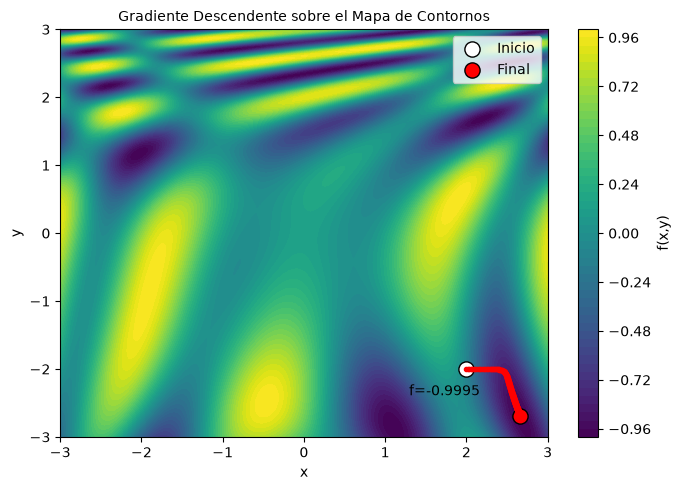

In [36]:
plt.figure(figsize=(7,5))
cont = plt.contourf(X, Y, Z, levels=50, cmap='viridis')

# Barra de colores
cbar = plt.colorbar(cont)
cbar.set_label('f(x,y)')

# Trayectoria
plt.plot(
    trayectoria[:,0],
    trayectoria[:,1],
    'r.-',
    linewidth=2
)

# Inicio
plt.scatter(
    trayectoria[0,0],
    trayectoria[0,1],
    c='white',
    s=120,
    edgecolors='black',
    label='Inicio'
)

# Final
plt.scatter(
    trayectoria[-1,0],
    trayectoria[-1,1],
    c='red',
    s=120,
    edgecolors='black',
    label='Final'
)

# Nota
plt.annotate(
    f"f={trayectoria[-1,2]:.4f}",
    (trayectoria[-1,0], trayectoria[-1,1]),
    xytext=(-80, 15),
    textcoords='offset points'
)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradiente Descendente sobre el Mapa de Contornos', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()


### Para $\alpha = 0.1$

Se obeserva que en la iteración 100 ya converge al mínimo global en valor, porque la función no puede tomar valores menores que -1.

Donde la función,
$$f(x, y) \approx -1$$

y sabamos además que,
$$-1 \leq \sin(A) \cos(B) \leq 1$$

por lo tanto,
$$f(x, y) \geq -1$$

In [37]:
trayectoria = gradiente_descendente(x0=2,y0=-2, alpha=0.1,iteraciones=500)

In [38]:
# Evolución
for i in range(0, len(trayectoria), 50):
    print(
        f"Iter {i:3d}: "
        f"x={trayectoria[i,0]:.4f}, "
        f"y={trayectoria[i,1]:.4f}, "
        f"f={trayectoria[i,2]:.6f}"
    )

Iter   0: x=2.0000, y=-2.0000, f=-0.114798
Iter  50: x=2.6630, y=-2.6964, f=-0.999571
Iter 100: x=2.6739, y=-2.7291, f=-1.000000
Iter 150: x=2.6742, y=-2.7300, f=-1.000000
Iter 200: x=2.6742, y=-2.7300, f=-1.000000
Iter 250: x=2.6742, y=-2.7300, f=-1.000000
Iter 300: x=2.6742, y=-2.7300, f=-1.000000
Iter 350: x=2.6742, y=-2.7300, f=-1.000000
Iter 400: x=2.6742, y=-2.7300, f=-1.000000
Iter 450: x=2.6742, y=-2.7300, f=-1.000000
Iter 500: x=2.6742, y=-2.7300, f=-1.000000


### Gráfico

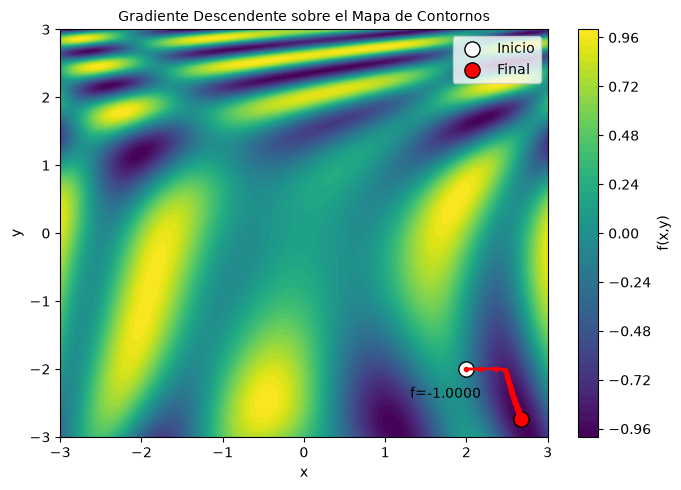

In [39]:
plt.figure(figsize=(7,5))
cont = plt.contourf(X, Y, Z, levels=50, cmap='viridis')

# Barra de colores
cbar = plt.colorbar(cont)
cbar.set_label('f(x,y)')

# Trayectoria
plt.plot(
    trayectoria[:,0],
    trayectoria[:,1],
    'r.-',
    linewidth=2
)

# Inicio
plt.scatter(
    trayectoria[0,0],
    trayectoria[0,1],
    c='white',
    s=120,
    edgecolors='black',
    label='Inicio'
)

# Final
plt.scatter(
    trayectoria[-1,0],
    trayectoria[-1,1],
    c='red',
    s=120,
    edgecolors='black',
    label='Final'
)

# Nota
plt.annotate(
    f"f={trayectoria[-1,2]:.4f}",
    (trayectoria[-1,0], trayectoria[-1,1]),
    xytext=(-80, 15),
    textcoords='offset points'
)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradiente Descendente sobre el Mapa de Contornos', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()


### Complejidad

Teniendo presente los dos métodos: def gradiente_numerico(...) y el def gradiente_descendente(...)

Entonces por Iteración se tiene:
+ 4 operaciones de f
+ algunas sumas
+ algunas multiplicaciones
+ Un append

Todo eso sería una constante $c$ de operaciones.

Si ejecutamos $n$ iteraciones entonces,

$$T(n) = c*n$$

Ejemplo si suponemos:

1 iteración $\approx$ 10 operaciones relevantes.

Entonces 
* 500 iteraciones $\approx$ 5000 operaciones relevantes.
* 1000 iteraciones $\approx$ 10000 operaciones relevantes.

La cantidad de operaciones crece linealmente, por eso $T(n) = c*n$ y en notación O() sería $O(n)$

El algoritmo ejecuta un ciclo de n iteraciones. En cada iteración se calcula el gradiente numérico mediante cuatro evaluaciones de la función objetivo y un número constante de operaciones aritméticas adicionales. Por lo tanto, el costo por iteración es constante $O(1)$, y la complejidad temporal total es lineal $O(n)$.

### Conclusiones

* La visualización de la función dada mediante superficie 3D y mapas de contornos permitió identificar regiones asociadas a mínimos y máximos locales. Esta información facilitó la selección de puntos iniciales para el algoritmo de gradiente descendente, evidenciando la influencia que tiene la elección del punto de partida en problemas de optimización no convexa.

* La elección del dominio para la visualización influye en la interpretación inicial del paisaje de optimización. En el intervalo $[−3,3]$ que elegí. Se observan ciertos valles y cimas, pero al ampliar por ejemplo el dominio a $[−5,5]$ aparecen nuevas regiones con otros mínimos y máximos locales. Esto refuerza la idea de que la función es no convexa y que el comportamiento del gradiente descendente dependerá tanto del punto inicial como de la región del dominio analizada.

* Al ampliar el dominio aparecen nuevos mínimos locales. Sin embargo, en esta función varios de esos mínimos alcanzan el mismo valor −1, por lo que existen múltiples mínimos globales (en valor), aunque ubicados en posiciones distintas del plano $(x, y)$.

* Para el punto inicial $(2,−2)$. La tasa $\alpha$ se seleccionó empíricamente. Se observó que α=0.01 proporciona una convergencia estable hacia un mínimo de la función, mientras que valores mayores podrían generar oscilaciones y valores menores aumentar innecesariamente el número de iteraciones requeridas, lo que se recomienda es hacer más experimentos o revisar la literatura para nuevos enfoques de usar $\alpha$. Por otro lado con una tasa de aprendizaje de $ \alpha =0.1$ permitió alcanzar la región del mínimo de forma considerablemente más rápida que $\alpha = 0.01$, manteniendo la estabilidad del algoritmo y evitando oscilaciones o divergencia.

* El AGD encontró un mínimo global en valor $(f = −1)$, aunque no necesariamente es el único punto donde dicho valor se alcanza.

### Ideas de mejoras

1. Se podría considerar un kit de inicialización para que desde diferentes partes del sistema de mueva en busca de encontrar el mínimo global. La idea de afinar $\alpha$ combinando pequeños saltos y luego saltos un poco más largo (Hammel, 2019), ayudarían a encontrar un poco más rápido el mínimo local o porque no el global.

2. Considerar el error para cortar anticipadamente el el proceso de encontrar el mínimo podría agilizar en vez de hacer la cantidad de iteraciones definidas al problema.

3. La estrategia del gradiente descendente estocástico támbién es una buena opción, pero sería más útil en proplemas de aprendizaje automático, donde el problema es de alta dimensionalidad y la cantidad de pesos sinápticos es miles de millones variables.

4. También, sería interesante probar la estrategia del gradiente conjugado (Shewchuk, 1994),

   $$ \beta = \frac{\nabla X_n^T (\nabla X_n - \nabla X_{n-1})}{\nabla X_{n-1}^T \nabla X_{n-1}} $$

   $$ S_n = \nabla X_n + \beta S_{n-1} $$

   La ubicación actual $X_{n}$ Se actualiza con esta dirección de búsqueda, utilizando un tamaño de paso $\alpha$ Calculado por búsqueda en línea,
   $$ X_{n+1} = X_n + \alpha S_n $$

### Referencias

+ Camacho, José M. (2026a). VC4 – Descenso del Gradiente: Algoritmos de Optimización [Archivo PDF]. Campus Virtual VIU. universidadviu.com

+ Camacho, José M. (2026b). AG2 – Actividad Guiada 2: 03MIAR – Algoritmos de Optimización [Archivo PDF]. Universidad Internacional de Valencia. universidadviu.com

+ Frederickson, B. (25 de noviembre de 2016). An Interactive Tutorial on Numerical Optimization. Ben Frederickson. https://www.benfrederickson.com/numerical-optimization/

+ Hammel, B. D. (2019, marzo 23). What learning rate should I use? B. D. Hammel. [bdhammel.com](http://www.bdhammel.com/learning-rates/)

+ Shewchuk, J. R. (1994). An introduction to the conjugate gradient method without the agonizing pain (Edition 1 1/4) [Informe técnico]. School of Computer Science, Carnegie Mellon University.


### Declaración de uso de IA

Se ha utilizado herramienta de IA generativa para formatear la citación a formato APA, revisar bibliografía, revisar algunas ortografías, formatear formulas en Markdown, y como herramienta consultiva para revisar instrucciones y/o errores del uso de sintaxis para Python.